<a href="https://colab.research.google.com/github/saqlainch8826/saqlainch8826.github.io/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Political Researcher & Data Analyst Portfolio
**Author:** Saqlain Haider  
**Focus:** Algorithmic Governance & Data-Driven Policy Evaluation

This notebook contains three main analyses:
1. **COMPAS Algorithmic Bias Audit** - Racial disparities in recidivism prediction
2. **Punjab Education Budget Efficiency** - Cost-effectiveness analysis of district spending
3. **Punjab Flood Impact Analysis** - Socio-economic damage visualization

---

---
## Project 1: COMPAS Algorithmic Bias Audit

**Objective:** Quantify racial disparities in criminal risk assessment algorithms  
**Data Source:** ProPublica COMPAS Recidivism Dataset  
**Key Finding:** 22% racial disparity in False Positive Rates (Black defendants: 45%, White defendants: 23%)  
**Methods:** Comparative statistical analysis, data visualization  
**Publication:** Published at paradigmshift.com.pk/algorithmic-governance/

---

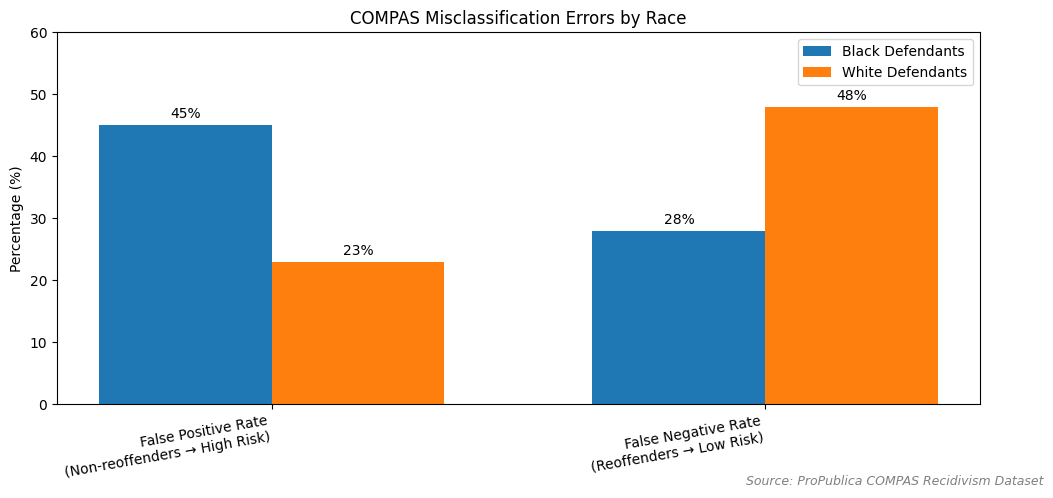

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categories = [
    "False Positive Rate\n(Non-reoffenders → High Risk)",
    "False Negative Rate\n(Reoffenders → Low Risk)"
]

black = [45, 28]
white = [23, 48]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(10, 5))

bars_black = plt.bar(x - width/2, black, width, label="Black Defendants", color="#1f77b4")
bars_white = plt.bar(x + width/2, white, width, label="White Defendants", color="#ff7f0e")

plt.ylabel("Percentage (%)")
plt.title("COMPAS Misclassification Errors by Race")
plt.xticks(x, categories, rotation=10, ha="right")
plt.ylim(0, 60)
plt.legend()

# Adding data labels on top of bars
for bars in [bars_black, bars_white]:
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha="center", va="bottom")

# Adding the source citation
plt.figtext(0.9, 0.02, "Source: ProPublica COMPAS Recidivism Dataset",
            horizontalalignment='center', fontsize=9, style='italic', color='grey')

plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

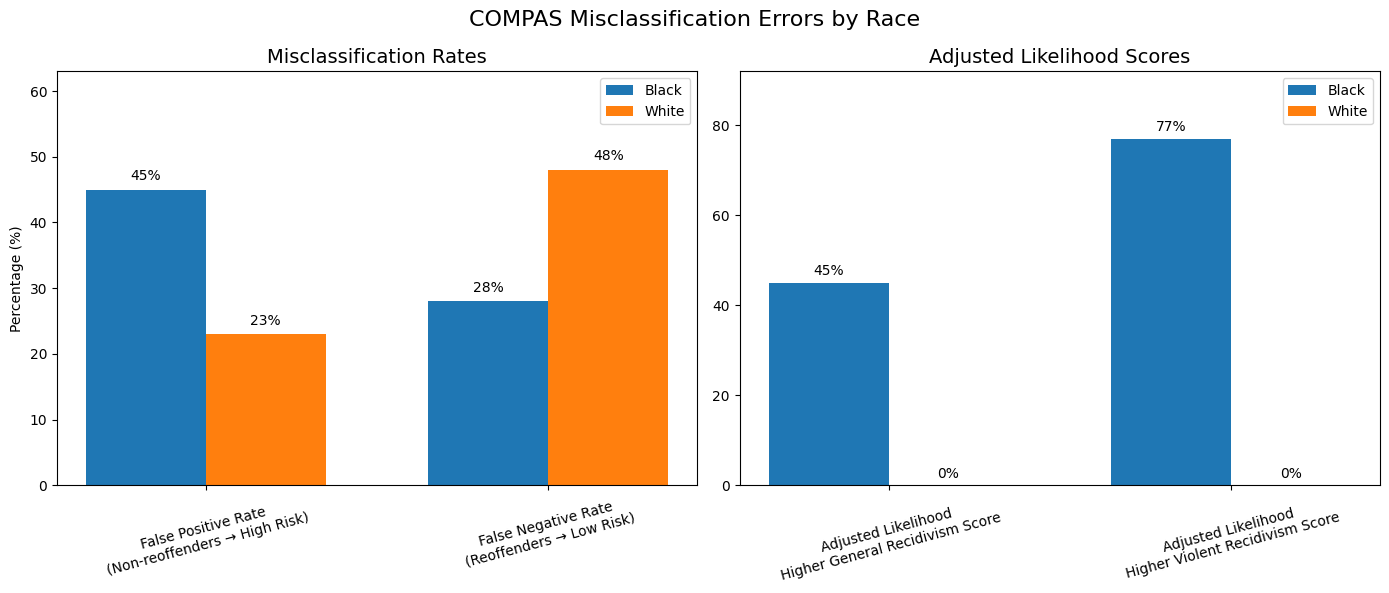

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

group1 = [
    "False Positive Rate\n(Non-reoffenders → High Risk)",
    "False Negative Rate\n(Reoffenders → Low Risk)"
]

group2 = [
    "Adjusted Likelihood\nHigher General Recidivism Score",
    "Adjusted Likelihood\nHigher Violent Recidivism Score"
]

black = [45, 28, 45, 77]
white = [23, 48, 0, 0]

x = np.arange(2)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ["#1f77b4", "#ff7f0e"]

for i in range(2):
    axes[0].bar(x[i] - width/2, black[i], width, color=colors[0], label="Black" if i==0 else "")
    axes[0].bar(x[i] + width/2, white[i], width, color=colors[1], label="White" if i==0 else "")
    axes[0].text(x[i] - width/2, black[i] + 1, f"{black[i]}%", ha='center', va='bottom', fontsize=10)
    axes[0].text(x[i] + width/2, white[i] + 1, f"{white[i]}%", ha='center', va='bottom', fontsize=10)

axes[0].set_xticks(x)
axes[0].set_xticklabels(group1, rotation=15, fontsize=10)
axes[0].set_ylabel("Percentage (%)")
axes[0].set_title("Misclassification Rates", fontsize=14)
axes[0].set_ylim(0, max(max(black[:2]), max(white[:2])) + 15)
axes[0].legend()

for i in range(2):
    axes[1].bar(x[i] - width/2, black[i+2], width, color=colors[0], label="Black" if i==0 else "")
    axes[1].bar(x[i] + width/2, white[i+2], width, color=colors[1], label="White" if i==0 else "")
    axes[1].text(x[i] - width/2, black[i+2] + 1, f"{black[i+2]}%", ha='center', va='bottom', fontsize=10)
    axes[1].text(x[i] + width/2, white[i+2] + 1, f"{white[i+2]}%", ha='center', va='bottom', fontsize=10)

axes[1].set_xticks(x)
axes[1].set_xticklabels(group2, rotation=15, fontsize=10)
axes[1].set_title("Adjusted Likelihood Scores", fontsize=14)
axes[1].set_ylim(0, max(max(black[2:]), max(white[2:])) + 15)
axes[1].legend()


fig.suptitle("COMPAS Misclassification Errors by Race", fontsize=16)

plt.tight_layout()

output_filename = "compas_2subplot_chart.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')

files.download(output_filename)

plt.show()

### Key Finding:
The COMPAS algorithm exhibits systematic racial bias:
- **False Positive Rate:** Black defendants are nearly twice as likely to be incorrectly labeled "high risk" (45% vs. 23%)
- **False Negative Rate:** White defendants are more likely to be incorrectly labeled "low risk" (48% vs. 28%)

This 22% disparity demonstrates how algorithmic systems can encode and amplify existing social inequalities, raising urgent questions about accountability in automated governance.

---
## Project 2: Punjab Education Governance - Budget Efficiency Analysis

**Objective:** Evaluate whether education spending correlates with literacy outcomes  
**Data Source:** Pakistan Bureau of Statistics (7th Census 2023), Punjab Finance Department (2024-25 Budget)  
**Key Finding:** High budget allocation does not guarantee high literacy rates  
**Methods:** Cost-per-literacy-point metric, dual-axis visualization

---

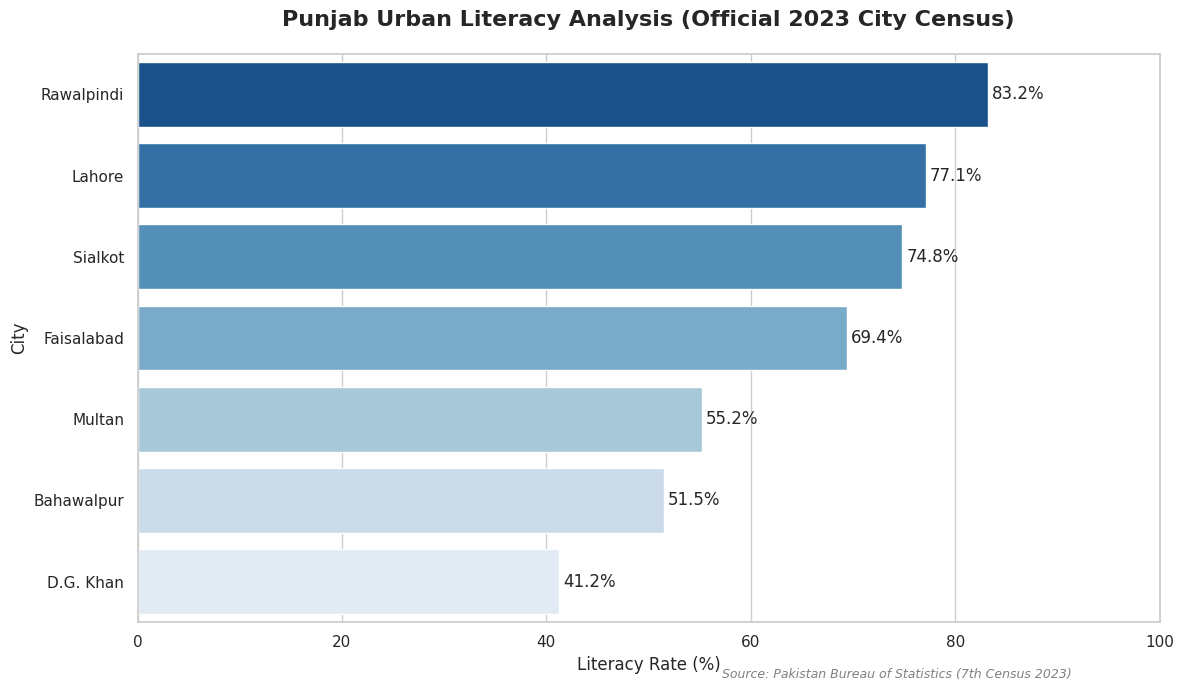

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


punjab_city_data = {
    "City": ["Rawalpindi", "Lahore", "Sialkot", "Faisalabad", "Multan", "Bahawalpur", "D.G. Khan"],
    "Literacy_Rate": [83.2, 77.1, 74.8, 69.4, 55.2, 51.5, 41.2],
    "Population_M": [3.36, 13.00, 1.01, 3.69, 2.22, 1.25, 0.68]
}

df = pd.DataFrame(punjab_city_data)

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

plot = sns.barplot(
    data=df,
    x='Literacy_Rate',
    y='City',
    hue='City',
    palette='Blues_r',
    legend=False
)

for i in plot.containers:
    plot.bar_label(i, padding=3, fmt='%.1f%%')

plt.title("Punjab Urban Literacy Analysis (Official 2023 City Census)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Literacy Rate (%)", fontsize=12)
plt.ylabel("City", fontsize=12)
plt.xlim(0, 100)

plt.figtext(0.9, 0.02, "Source: Pakistan Bureau of Statistics (7th Census 2023)",
            horizontalalignment='right', fontsize=9, style='italic', color='grey')

plt.tight_layout()
plt.show()

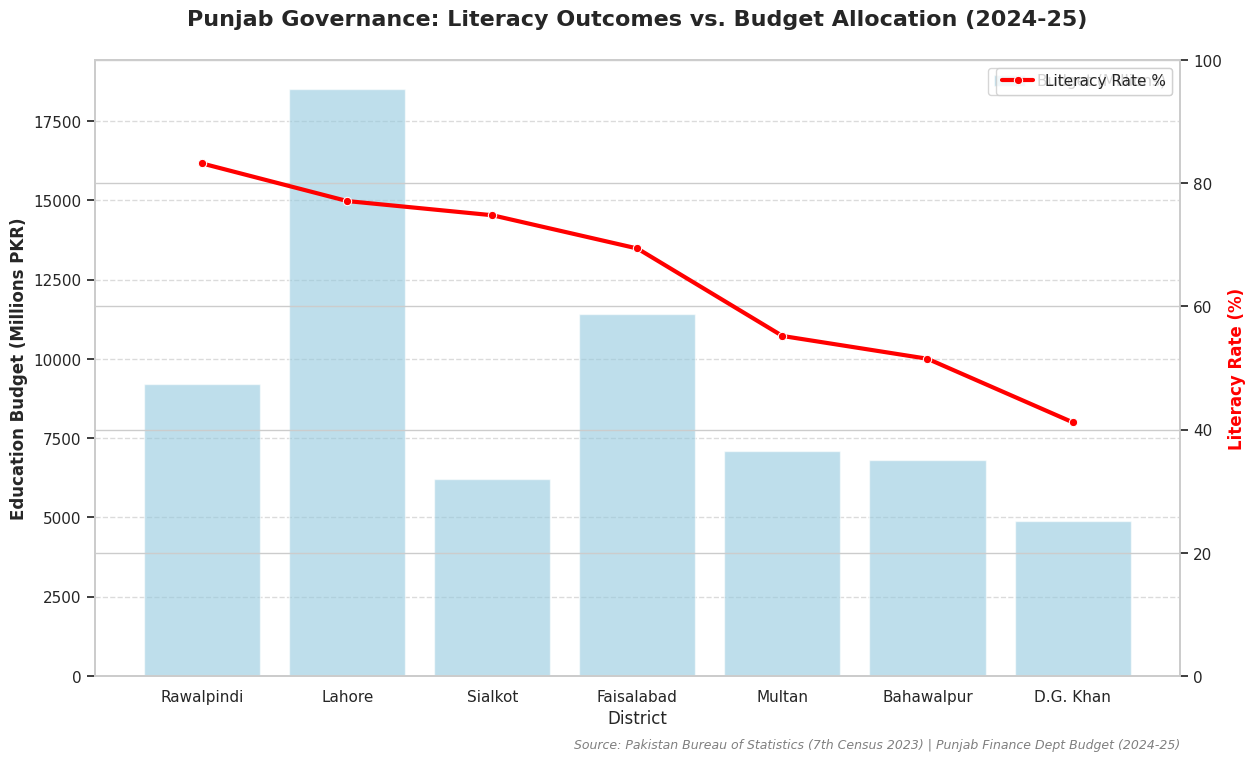

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

punjab_governance = {
    "District": ["Rawalpindi", "Lahore", "Sialkot", "Faisalabad", "Multan", "Bahawalpur", "D.G. Khan"],
    "Literacy_Rate": [83.2, 77.1, 74.8, 69.4, 55.2, 51.5, 41.2],
    "Population_M": [5.4, 13.0, 4.4, 7.8, 4.7, 4.1, 3.6],
    "Edu_Budget_M": [9200, 18500, 6200, 11400, 7100, 6800, 4900]
}

df = pd.DataFrame(punjab_governance)

df['Cost_Per_Literacy_Point'] = (df['Edu_Budget_M'] / df['Literacy_Rate']).round(2)

fig, ax1 = plt.subplots(figsize=(14, 8))

sns.barplot(data=df, x='District', y='Edu_Budget_M', alpha=0.6, color='skyblue', label='Budget (Millions)', ax=ax1)
ax1.set_ylabel("Education Budget (Millions PKR)", fontsize=12, fontweight='bold')

ax2 = ax1.twinx()
sns.lineplot(data=df, x='District', y='Literacy_Rate', color='red', marker='o', linewidth=3, label='Literacy Rate %', ax=ax2)
ax2.set_ylabel("Literacy Rate (%)", fontsize=12, fontweight='bold', color='red')
ax2.set_ylim(0, 100)

plt.title("Punjab Governance: Literacy Outcomes vs. Budget Allocation (2024-25)", fontsize=16, fontweight='bold', pad=25)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

plt.figtext(0.9, 0.02, "Source: Pakistan Bureau of Statistics (7th Census 2023) | Punjab Finance Dept Budget (2024-25)",
            horizontalalignment='right', fontsize=9, style='italic', color='grey')

plt.show()

### Key Observation:
Districts with higher education budgets do not consistently achieve higher literacy rates. Rawalpindi achieves higher literacy outcomes with a smaller education budget compared to Lahore. This suggests governance efficiency and implementation quality matter more than budget size alone.

---
## Project 3: Punjab Floods 2025 - Socio-Economic Impact

**Objective:** Visualize the human and economic toll of climate-related disasters  
**Data Source:** UN official reports and Pakistan's news sources  
**Methods:** Data visualization using Matplotlib

---

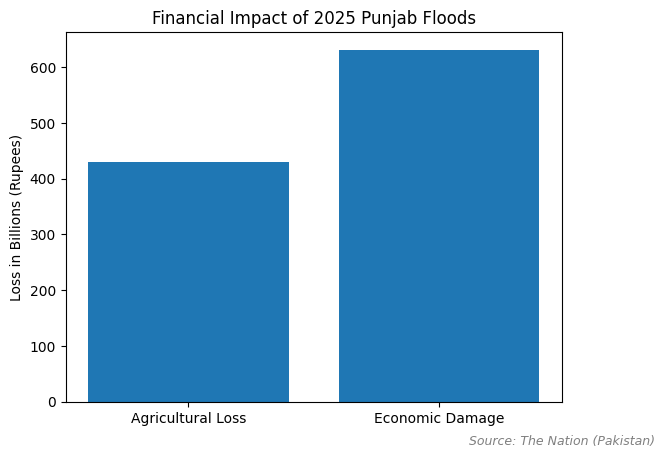

In [ ]:
import matplotlib.pyplot as plt

agricultural_loss_billion = 430
economic_damage_billion = 631

categories = ["Agricultural Loss", "Economic Damage"]
values = [agricultural_loss_billion, economic_damage_billion]

plt.bar(categories, values)
plt.title("Financial Impact of 2025 Punjab Floods")
plt.ylabel("Loss in Billions (Rupees)")

plt.figtext(0.9, 0.02, "Source: The Nation (Pakistan)",
            horizontalalignment='center', fontsize=9, style='italic', color='grey')

plt.show()

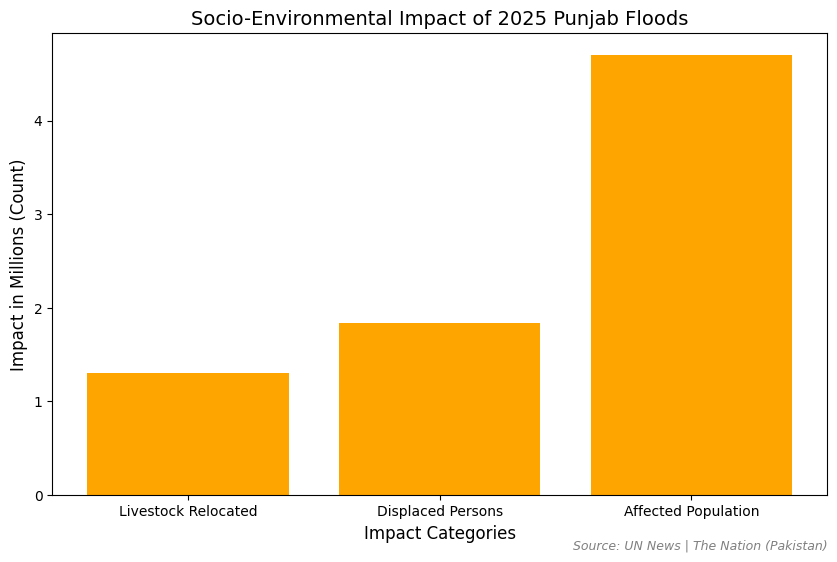

In [ ]:
import matplotlib.pyplot as plt


livestock_relocated_million = 1.3
displaced_persons_million = 1.839
affected_population_million = 4.7

categories_social = ["Livestock Relocated", "Displaced Persons", "Affected Population"]
values_social = [livestock_relocated_million, displaced_persons_million, affected_population_million]

plt.figure(figsize=(10, 6))
plt.bar(categories_social, values_social, color='orange')

plt.title("Socio-Environmental Impact of 2025 Punjab Floods", fontsize=14)
plt.ylabel("Impact in Millions (Count)", fontsize=12)
plt.xlabel("Impact Categories", fontsize=12)

plt.figtext(0.9, 0.02, "Source: UN News | The Nation (Pakistan)",
            horizontalalignment='right', fontsize=9, style='italic', color='grey')

plt.show()


#Additional Visualizations: Practicing issues currently in the news

/tmp/ipython-input-2202902345.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Reserves', y='Country', data=df_oil, palette=colors, ax=ax)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

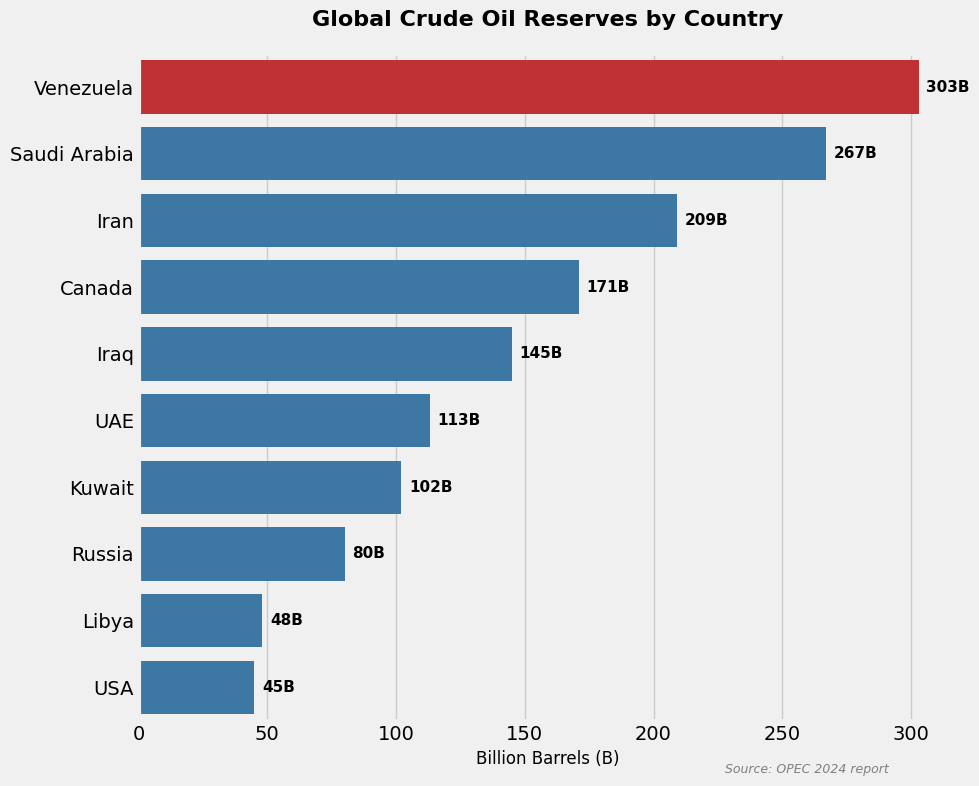

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import files

oil_data = {
    "Country": ["Venezuela", "Saudi Arabia", "Iran", "Canada", "Iraq", "UAE", "Kuwait", "Russia", "Libya", "USA"],
    "Reserves": [303, 267, 209, 171, 145, 113, 102, 80, 48, 45]
}
df_oil = pd.DataFrame(oil_data)

plt.style.use('fivethirtyeight')
fig, ax = plt.subplots(figsize=(10, 8))


colors = ['#d7191c' if country == 'Venezuela' else '#2c7bb6' for country in df_oil['Country']]

sns.barplot(x='Reserves', y='Country', data=df_oil, palette=colors, ax=ax)


for i, v in enumerate(df_oil['Reserves']):
    ax.text(v + 3, i, f"{v}B", color='black', va='center', fontweight='bold', fontsize=11)


ax.set_title("Global Crude Oil Reserves by Country", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Billion Barrels (B)", fontsize=12)
ax.set_ylabel("")


plt.figtext(0.9, 0.02, "Source: OPEC 2024 report",
            horizontalalignment='right', fontsize=9, style='italic', color='grey')


plt.tight_layout()
plt.savefig("global_oil_reserves.png", dpi=300, bbox_inches='tight')
files.download("global_oil_reserves.png")

plt.show()

#Practice

In [ ]:
import pandas as pd

governance_data = {
    "District": ["Lahore", "Faisalabad", "Rawalpindi", "Multan", "Gujranwala"],
    "Education_Budget_M": [450, 320, 290, 210, 180],
    "Literacy_Rate": [77, 69, 75, 62, 65],
    "Population_M": [11.1, 3.2, 2.1, 1.9, 2.0]
}

df=pd.DataFrame(governance_data)

print("---Policy DataFrame---")
print(df.describe())


---Policy DataFrame---
       Education_Budget_M  Literacy_Rate  Population_M
count            5.000000       5.000000      5.000000
mean           290.000000      69.600000      4.060000
std            106.066017       6.387488      3.970264
min            180.000000      62.000000      1.900000
25%            210.000000      65.000000      2.000000
50%            290.000000      69.000000      2.100000
75%            320.000000      75.000000      3.200000
max            450.000000      77.000000     11.100000


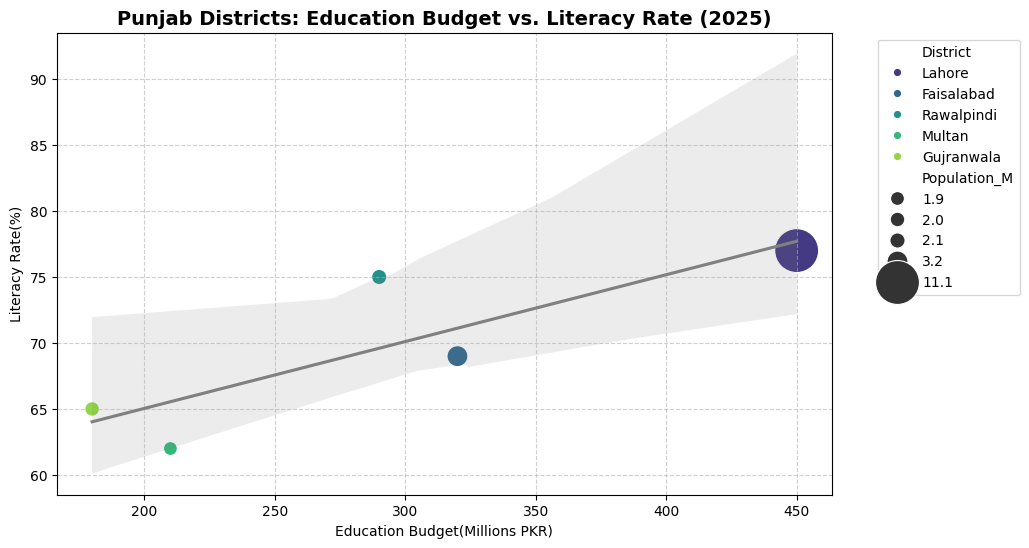

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="Education_Budget_M", y="Literacy_Rate",
                size="Population_M", hue="District", sizes=(100, 1000), palette="viridis")

sns.regplot(data=df, x="Education_Budget_M", y="Literacy_Rate", scatter=False, color="grey")

plt.title("Punjab Districts: Education Budget vs. Literacy Rate (2025)", fontsize=14, fontweight='bold')
plt.xlabel("Education Budget(Millions PKR)")
plt.ylabel("Literacy Rate(%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()
